# Effect of the FIFA sponsorship on Lenovo's brand

> **Primary estimate (ADR-0043): the FIFA-specific effect** (section 5.8): the part of Lenovo's gap to its no-sponsorship twin explained by accumulated FIFA exposure, after Lenovo's other sponsorships and events. The total effect (section 5.1) is its upper attribution band.

**Review notebook** for the project's headline estimate, `sponsorship_total_effect_v1` (ADR-0034, ADR-0035, ADR-0038), measured on the Lenovo Brand Index (brand share of attention against rivals, informed by the GWI survey; ADR-0039, ADR-0040; construction in `05_brand_index.ipynb`). Two cross-checks are shown: the same design on Google share of search alone, and the former headline on the superseded search-salience index. The original 2024 design (`sponsorship_counterfactual_v1`, on the search-salience index) is shown for context with its media-value weighting sensitivity (ADR-0028). It follows the human-review standard in `AGENTS.md`. A close-up on the World Cup is in `20_world_cup_close_up.ipynb`.

*How to use:* run all cells. The notebook only reads production outputs and imports production code; it never rewrites data unless `RUN_REBUILD` is set to `True` in the first code cell. Every number in the narrative is computed from the current outputs when the notebook runs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: regenerates the outputs read below (several minutes)
    subprocess.run([sys.executable, "-m", "srmp.experiments.sponsorship_counterfactual_v1"], check=True)
    for cfg in ["sponsorship_total_effect_v1", "sponsorship_total_effect_share_of_search_v1",
                "sponsorship_total_effect_search_salience_v1"]:
        subprocess.run([sys.executable, "-m", "srmp.experiments.sponsorship_total_effect_v1",
                        "--config", f"config/experiments/{cfg}.yaml"], check=True)

E = "data/curated/experimental/"
T = E + "sponsorship_total_effect_v1/"
SS, SAL = E + "sponsorship_total_effect_share_of_search_v1/", E + "sponsorship_total_effect_search_salience_v1/"
SOURCES = [
    "data/curated/index/brand_index_weekly.parquet", "data/curated/index/brand_index_manifest.json",
    "data/curated/trends/jointly_scaled_donor_trends.parquet",
    "data/curated/trends/trends_weekly_averaged.parquet",
    "data/reference/counterfactual_donor_registry.csv",
    "config/experiments/sponsorship_total_effect_v1.yaml",
    T + "selection_record.json", T + "selection_table.parquet", T + "estimate_manifest.json",
    T + "total_effect_weekly.parquet", T + "donor_sensitivity.parquet", T + "specification_curve.parquet",
    E + "sponsorship_counterfactual_v1/counterfactual_manifest.json",
    E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json",
    "config/experiments/sponsorship_total_effect_share_of_search_v1.yaml",
    "config/experiments/sponsorship_total_effect_search_salience_v1.yaml",
    SS + "estimate_manifest.json", SS + "specification_curve.parquet",
    SAL + "estimate_manifest.json", SAL + "specification_curve.parquet",
    "config/experiments/sponsorship_exposure_timing_v1.yaml", "data/staged/blinkfire/blinkfire_exposure_weekly.parquet",
    E + "sponsorship_exposure_timing_v1/exposure_timing_manifest.json",
    E + "sponsorship_exposure_timing_v1/exposure_timing_coefficients.parquet",
    E + "sponsorship_exposure_timing_v1/exposure_timing_weekly.parquet",
    E + "sponsorship_exposure_timing_v1/nonfifa_backcast_scales.parquet",
    E + "sponsorship_exposure_timing_v1/fifa_specific_decomposition.parquet",
    E + "tv_exposure_check_v1/tv_exposure_check_manifest.json",
    E + "tv_exposure_check_v1/tv_exposure_weekly_relative.parquet",
]
stamp_sources(SOURCES)
est = json.loads(Path(T + "estimate_manifest.json").read_text())
effect, p = est["total_effect"], est["primary"]

REVIEW_SOURCES={"data/curated/index/brand_index_weekly.parquet": "b8599ec9976546d21f2298a5de21c25869eb565e41319e67d69ffae7d2182b7d", "data/curated/index/brand_index_manifest.json": "810c5146f22de97d0c2e92409422d1f33e03257ffff0615787c89c8e0f2f9c70", "data/curated/trends/jointly_scaled_donor_trends.parquet": "d03dea0cf14b0af202f704502829d0801ba2763df187b0be17881f1309aaf4a7", "data/curated/trends/trends_weekly_averaged.parquet": "6b114d3b23ba37aa4cbacb6e8e7ba21cf469f73537454ece108ae10690b37134", "data/reference/counterfactual_donor_registry.csv": "d3e93f01eeca4b42c4f6cfb0734b6ff10687e83014cbc8633f40b3d157972475", "config/experiments/sponsorship_total_effect_v1.yaml": "0a45b84df66f240e4b766b0a962c254b6859e48c8100ee4fc269fcc6241efb6d", "data/curated/experimental/sponsorship_total_effect_v1/selection_record.json": "191bd0d19c12a955d3b1bf77f064e8d171b78d9b87f4ed130dfd486f2350201b", "data/curated/experimental/sponsorship_total_effect_v1/selection_table.parquet": "aec6505005f129f60ca20da7abea7f

## 1. Question and purpose

**Question.** Over the whole sponsorship so far, from the partnership announcement on 15 October 2024 through the 2026 World Cup and the weeks after it, how much higher is Lenovo's brand share of attention, as measured by the Brand Index, than it would have been without the FIFA sponsorship?

**Why it matters.** This is the base of the project's sponsorship estimate: the total effect here, and its FIFA-specific part in section 5.8. Valuation and any return-on-sponsorship estimate are built on it. The World Cup is part of this period, not a separate claim; it is examined in close-up in notebook 20.

**Objective supported.** Measuring the sponsorship's total brand uplift before any monetisation.

## 2. Evidence and inputs

| Input | What it is | Source | Label |
|---|---|---|---|
| Lenovo Brand Index | Weekly brand share of attention: a factor model of Lenovo's Google share of search against rival brands, with GWI engagement and consideration as quarterly measurements. 100 = pre-announcement average; 1 point ≈ 1% of that share | Google Trends; GWI | **constructed** (see `05_brand_index.ipynb`) |
| Rival ("donor") brands | Weekly Google Trends interest for 26 screened rival tech brands, pulled in panels sharing a "Lenovo" anchor so all sit on one scale, then expressed on the Brand Index basis: each rival's share of search against the other base rivals (Lenovo excluded) | Google Trends | **observed**, then **constructed** (common-anchor rescaling, share) |
| Donor registry | Which brands may serve as comparisons, after screening for FIFA/World Cup sponsorship and data quality | FIFA partner lists, brand news, our screen | **assumed** (evidence-bounded) |
| Media value | Vendor media-equivalency by FIFA competition and market, used only as a relative weight in a sensitivity | Client export | **estimated** by the vendor |

In [2]:
index = pd.read_parquet("data/curated/index/brand_index_weekly.parquet")
donors = pd.read_parquet("data/curated/trends/jointly_scaled_donor_trends.parquet")
registry = pd.read_csv("data/reference/counterfactual_donor_registry.csv")
weekly = pd.read_parquet(T + "total_effect_weekly.parquet"); weekly["week"] = pd.to_datetime(weekly["week"])
display(pd.DataFrame([
    {"Input": "Lenovo Brand Index (weeks)", "First": str(index["week"].min()), "Last": str(index["week"].max()), "Count": len(index)},
    {"Input": "Donor panels (Trends weeks)", "First": str(donors["week"].min())[:10], "Last": str(donors["week"].max())[:10], "Count": donors["query_id"].nunique()},
    {"Input": "Estimation panel (provisional weeks excluded)", "First": str(weekly["week"].min().date()), "Last": str(weekly["week"].max().date()), "Count": len(weekly)},
]).rename(columns={"Count": "Weeks (donor panels: queries)"}))
display(registry["inclusion_policy"].value_counts().rename_axis("Donor registry policy").rename("Brands").to_frame())

,Input,First,Last,Weeks (donor panels: queries)
0,Lenovo Brand Index (weeks),2022-01-03,2026-09-28,248
1,Donor panels (Trends weeks),2021-12-26,2026-09-27,38
2,Estimation panel (provisional weeks excluded),2022-01-03,2026-09-14,246


,Brands
Donor registry policy,
candidate_base,15
base,11
data_quality_excluded,7
excluded,2
sensitivity,2


**Reading the registry.** `base`: screened clean in July 2026 (ADR-0021); `candidate_base`: added and screened in October 2026 (ADR-0035); `sensitivity`: used only in robustness checks; `excluded`: FIFA or World Cup activity found; `data_quality_excluded`: mostly empty or constant search series before the announcement.

## 3. Method and formulas

**Synthetic control.** Lenovo cannot be observed without the sponsorship, so a "synthetic Lenovo" is built from a weighted mix of rival brands that tracked Lenovo closely *before* the announcement; its later path stands in for Lenovo without the sponsorship.

All series are standardised with their own pre-announcement mean and standard deviation, so post-announcement data never influence scaling. For Lenovo $y_t$ and donors $x_{jt}$ in these units, the simplex weights solve

$$\hat w = \arg\min_{w} \sum_{t < T_0} \Big(y_t - \sum_j w_j x_{jt}\Big)^2 \quad \text{s.t. } w_j \ge 0,\ \sum_j w_j = 1 .$$

*In words:* the non-negative mix of rival brands, adding to 100%, that best reproduces Lenovo before $T_0$ = 21 October 2024 (first full week after the announcement).

The weekly **gap** in Brand Index points, and the **total effect**:

$$\text{gap}_t = \sigma_y \Big(y_t - \sum_j \hat w_j x_{jt}\Big), \qquad \text{Total effect} = \frac{1}{|P|}\sum_{t \in P} \text{gap}_t ,$$

where $\sigma_y$ is Lenovo's pre-announcement standard deviation in Index points and $P$ is every week from $T_0$ to the latest non-provisional week. *In words:* the average amount by which Lenovo sits above its no-sponsorship twin over the sponsorship so far.

**Placebo test (pre-registered).** Each rival is treated as if it had been sponsored, with its own twin built from the other rivals. With the post/pre RMSPE ratio $R = \sqrt{\overline{\text{gap}^2}_{post}} / \sqrt{\overline{\text{gap}^2}_{pre}}$,

$$p = \frac{1 + \#\{\text{rivals with } R_j \ge R_{Lenovo}\}}{1 + J}.$$

*In words:* the share of rival brands that diverge from their own twins at least as much as Lenovo does. Threshold: $p \le 0.10$; with $J$ rivals the smallest possible $p$ is $1/(1+J)$.

**Rivals on the same basis.** Each rival $j$ enters as $x_{jt} = \log V_{jt} - \log \sum_{r \in R,\, r \ne j} V_{rt}$: its search volume $V$ relative to the other base rivals $R$. Lenovo is in no denominator, so a sponsorship lift for Lenovo cannot mechanically lower its comparison brands (`donor_shares_of_search`). Rivals have no survey series, so the twin reproduces the search component of the index only.

**Design chosen on pre-period evidence only.** Twelve or more candidate designs (simplex SCM, augmented SCM, synthetic DiD, factor model × donor pools) predict Lenovo in four rolling 16-week pre-announcement folds; the lowest out-of-sample error wins. No post-announcement data enter the choice.

The formulas above show the simplex case; the selected design (section 5.2) may be augmented SCM, synthetic DiD or the factor model, all fitted on the same standardised series.

**Reading the unit.** The Brand Index is proportional to Lenovo's brand share of attention (zero share = 0), so a lift $\Delta$ over the no-sponsorship level $I_{cf}$ is a $\Delta / I_{cf}$ percentage uplift in brand share.

## 4. Calculation path

| Step | Reproducible code | Configuration | Output read here |
|---|---|---|---|
| Lenovo and donor Trends panels | `srmp/ingest/trends.py`, `srmp/ingest/trends_joint.py` | `config/queries_trends.yaml`, `config/joint_trends_donors.yaml` | `data/curated/trends/` |
| Brand Index | `srmp/index/brand_factor.py` | `config/brand_index.yaml` | `data/curated/index/brand_index_weekly.parquet` |
| Design selection, total effect, placebos, weekly path, specification curve | `srmp/experiments/sponsorship_total_effect_v1.py` (`select_design`, `build`) with `srmp/counterfactual/scm.py` | `config/experiments/sponsorship_total_effect_v1.yaml` | `sponsorship_total_effect_v1/` |
| Cross-checks (share of search only; search-salience index) | same module, `--config` | `sponsorship_total_effect_share_of_search_v1.yaml`, `sponsorship_total_effect_search_salience_v1.yaml` | `sponsorship_total_effect_share_of_search_v1/`, `sponsorship_total_effect_search_salience_v1/` |
| Original 2024 design and media-value sensitivity (search-salience index) | `srmp/experiments/sponsorship_counterfactual_v1.py` | `config/experiments/sponsorship_counterfactual_v1.yaml` | `sponsorship_counterfactual_v1/` |
| FIFA vs other sponsorships (exposure timing) | `srmp/experiments/sponsorship_exposure_timing_v1.py` | `config/experiments/sponsorship_exposure_timing_v1.yaml` | `sponsorship_exposure_timing_v1/` |
| Television check of the FIFA-specific effect (ADR-0046) | `srmp/experiments/tv_exposure_check_v1.py` | `config/experiments/tv_exposure_check_v1.yaml` | `tv_exposure_check_v1/` |
| Everything, in order | `python -m srmp.pipeline` | — | — |

## 5. Results

### 5.1 The headline: Lenovo vs its no-sponsorship twin

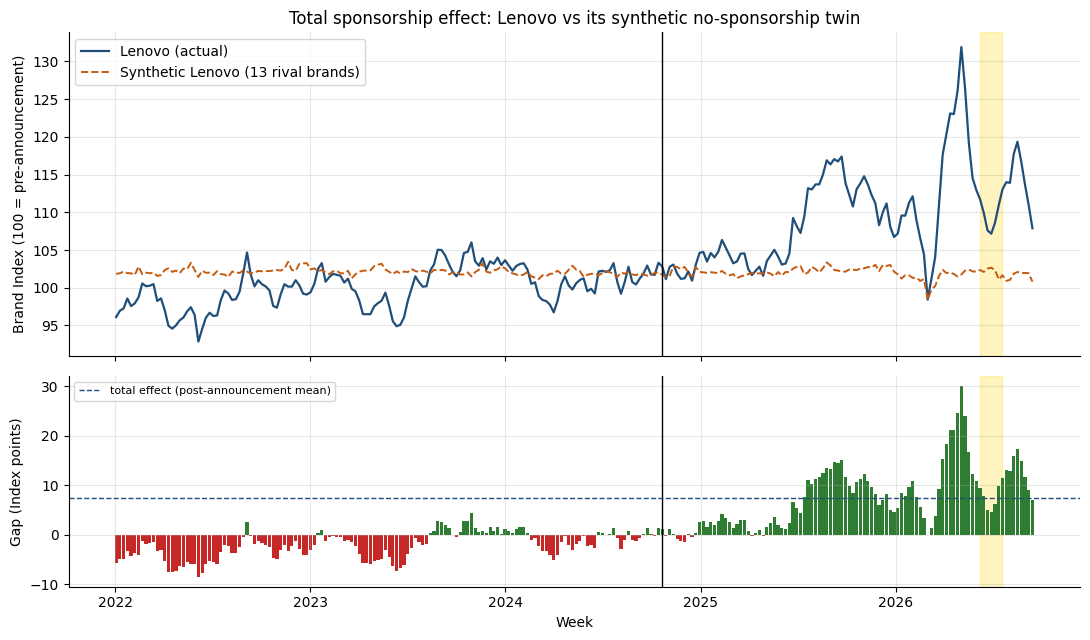

**Figure 1.** Vertical line: 2024-10-21, first full week after the announcement. Gold band: Men's World Cup. Pre-announcement fit error 3.39 Index points. Total effect over 100 weeks (2024-10-21 to 2026-09-14): **+7.48 Index points**.

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.3]})
ax1.plot(weekly["week"], weekly["actual_index"], label="Lenovo (actual)", color="#1f4e79", lw=1.6)
ax1.plot(weekly["week"], weekly["synthetic_index"], label=f"Synthetic Lenovo ({len(est['selection']['selected_donors'])} rival brands)",
         color="#c55a11", lw=1.4, ls="--")
for a in (ax1, ax2):
    a.axvline(pd.Timestamp(effect["first_post_week"]), color="black", lw=1)
    a.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.25)
ax1.set_ylabel("Brand Index (100 = pre-announcement)"); ax1.set_title("Total sponsorship effect: Lenovo vs its synthetic no-sponsorship twin")
ax1.legend(loc="upper left")
ax2.bar(weekly["week"], weekly["index_gap"], width=6, color=np.where(weekly["index_gap"] >= 0, "#2e7d32", "#c62828"))
ax2.axhline(effect["lift_index_points"], color="#1f4e79", ls="--", lw=1, label="total effect (post-announcement mean)")
ax2.set_ylabel("Gap (Index points)"); ax2.set_xlabel("Week"); ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
md(f"**Figure 1.** Vertical line: {effect['first_post_week']}, first full week after the announcement. Gold band: Men's World Cup. "
   f"Pre-announcement fit error {fmt(p['pre_rmspe_index_points'])} Index points. Total effect over {effect['post_weeks']} weeks "
   f"({effect['first_post_week']} to {effect['last_week']}): **{fmt(effect['lift_index_points'], signed=True)} Index points**.")

In [4]:
phases = [("Before the announcement (fit period)", "2022-01-01", "2024-10-20"),
          ("Announcement quarter", "2024-10-21", "2024-12-31"), ("Early 2025", "2025-01-01", "2025-06-08"),
          ("Club World Cup 2025", "2025-06-09", "2025-07-13"), ("H2 2025 (U-17, U-20 World Cups)", "2025-07-14", "2025-12-31"),
          ("Q1 2026 (CES)", "2026-01-01", "2026-03-15"), ("Spring 2026 PC-price surge (confounded)", "2026-03-16", "2026-06-07"),
          ("Men's World Cup", "2026-06-08", "2026-07-19"), ("After the final", "2026-07-20", effect["last_week"]),
          ("TOTAL sponsorship period", effect["first_post_week"], effect["last_week"])]
table = pd.DataFrame([{"Period": name, "From": a, "To": b,
                       "Weeks": int(((weekly["week"] >= a) & (weekly["week"] <= b)).sum()),
                       "Mean gap (Index points)": weekly.loc[(weekly["week"] >= a) & (weekly["week"] <= b), "index_gap"].mean()}
                      for name, a, b in phases])
display(table.style.format({"Mean gap (Index points)": "{:+.2f}"}).hide(axis="index"))
md("**Table 1.** The total effect broken down by period (descriptive; only the total is tested). The lift builds over time rather than "
   "jumping at the announcement. The spring 2026 period coincides with a category-wide surge in PC-brand searches (section 5.5).")

Period,From,To,Weeks,Mean gap (Index points)
Before the announcement (fit period),2022-01-01,2024-10-20,146,-2.07
Announcement quarter,2024-10-21,2024-12-31,11,+0.10
Early 2025,2025-01-01,2025-06-08,22,+1.98
Club World Cup 2025,2025-06-09,2025-07-13,5,+4.00
"H2 2025 (U-17, U-20 World Cups)",2025-07-14,2025-12-31,25,+10.38
Q1 2026 (CES),2026-01-01,2026-03-15,10,+6.00
Spring 2026 PC-price surge (confounded),2026-03-16,2026-06-07,12,+17.33
Men's World Cup,2026-06-08,2026-07-19,6,+7.14
After the final,2026-07-20,2026-09-14,9,+12.56
TOTAL sponsorship period,2024-10-21,2026-09-14,100,+7.48


**Table 1.** The total effect broken down by period (descriptive; only the total is tested). The lift builds over time rather than jumping at the announcement. The spring 2026 period coincides with a category-wide surge in PC-brand searches (section 5.5).

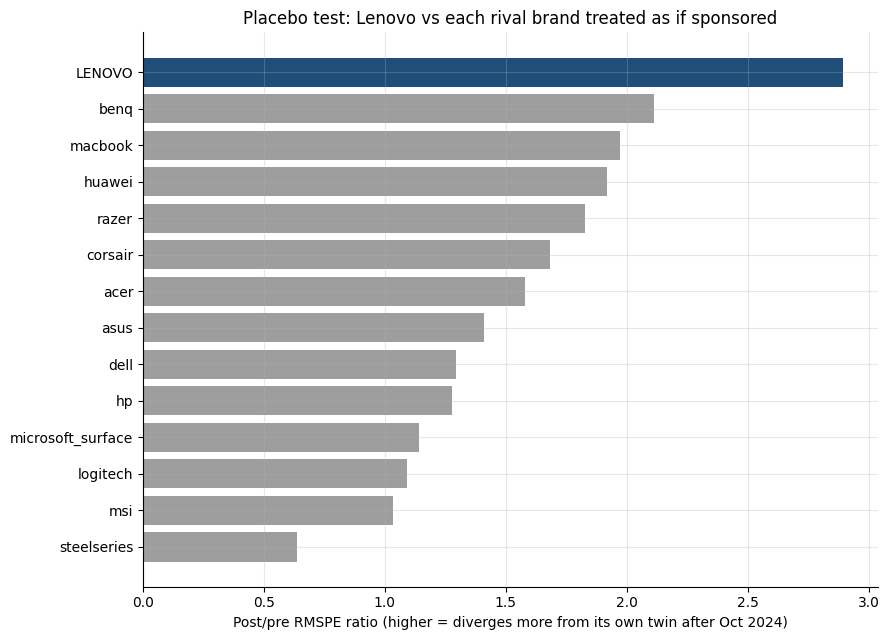

**Figure 2.** Rival brands diverging at least as much as Lenovo: none. p = **0.071** with 13 placebos (threshold 0.10; smallest possible 0.071). Result: **passes** the pre-registered test.

In [5]:
pls = pd.DataFrame(p["placebos"])
units = list(pls["placebo_unit"].str.replace("donor_", "")) + ["LENOVO"]
vals = list(pls["rmspe_ratio"]) + [p["treated_statistic"]]
order = np.argsort(vals)
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(np.array(units)[order], np.array(vals)[order], color=["#1f4e79" if u == "LENOVO" else "#9e9e9e" for u in np.array(units)[order]])
ax.set_xlabel("Post/pre RMSPE ratio (higher = diverges more from its own twin after Oct 2024)")
ax.set_title("Placebo test: Lenovo vs each rival brand treated as if sponsored")
plt.tight_layout(); plt.show()
above = pls.loc[pls["rmspe_ratio"] >= p["treated_statistic"], "placebo_unit"].str.replace("donor_", "").tolist()
md(f"**Figure 2.** Rival brands diverging at least as much as Lenovo: {', '.join(above) if above else 'none'}. "
   f"p = **{fmt(p['p_value'], 3)}** with {p['placebos_kept']} placebos (threshold 0.10; smallest possible {fmt(1/(1+p['placebos_kept']), 3)}). "
   f"Result: **{'passes' if est['passes_primary_test'] else 'does not pass'}** the pre-registered test.")

In [6]:
loo = pd.read_parquet(T + "donor_sensitivity.parquet")
md(f"**Leave-one-donor-out.** Dropping each rival brand in turn, the total effect ranges "
   f"{fmt(effect['leave_one_donor_out_range'][0], signed=True)} to {fmt(effect['leave_one_donor_out_range'][1], signed=True)} Index points "
   f"(largest change when dropping {loo.loc[(loo['post_mean_gap'] - effect['lift_index_points']).abs().idxmax(), 'specification'].replace('leave_out_donor_', '')}): "
   "no single rival drives the result.")

**Leave-one-donor-out.** Dropping each rival brand in turn, the total effect ranges +6.99 to +9.87 Index points (largest change when dropping razer): no single rival drives the result.

### 5.2 How the design was chosen

In [7]:
record = json.loads(Path(T + "selection_record.json").read_text())
sel = pd.read_parquet(T + "selection_table.parquet")
display(sel.drop(columns=["folds"]).head(10).rename(columns={
    "donor_pool": "Donor pool", "method": "Method", "donors": "Donors", "oos_rmspe_index_points": "Out-of-sample RMSE (Index pts)",
    "oos_mean_error_index_points": "Mean error (pts)", "worst_fold_mean_error": "Worst fold mean error"}).style.format(precision=3).hide(axis="index"))
cf = json.loads(Path(E + "sponsorship_counterfactual_v1/counterfactual_manifest.json").read_text())
md(f"**Table 2.** Ten best of {len(sel)} candidate designs, scored only on pre-announcement weeks "
   f"({record['data_weeks_seen'][0]} to {record['data_weeks_seen'][1]}; post-period accessed: {record['post_period_outcomes_accessed']}). "
   f"Selected by rule: **{record['selected_method']} on the '{record['selected_pool']}' pool ({len(record['selected_donors'])} donors)**. "
   f"For context, the original 2024 design (11 donors, on the superseded search-salience index, in its own 100/15 points) gives a post-announcement mean gap of "
   f"{fmt(cf['candidate_attribution']['all_post_mean_delta_index'], signed=True)} with p = {fmt(cf['diagnostics']['donor_placebo_p_value'], 3)}. "
   f"Mean pre-period error of the selected design: {fmt(sel.iloc[0]['oos_mean_error_index_points'], signed=True)} points "
   f"({'Lenovo slightly under-predicted' if sel.iloc[0]['oos_mean_error_index_points'] > 0 else 'Lenovo slightly over-predicted'} even before the announcement).")

Donor pool,Method,Donors,Out-of-sample RMSE (Index pts),Mean error (pts),Worst fold mean error
base_plus_sensitivity,synthetic_did,13,2.722,1.737,4.085
expanded,synthetic_did,26,2.807,1.290,3.652
expanded_plus_sensitivity,synthetic_did,28,2.851,1.460,4.286
base_plus_sensitivity,generalized_scm_factor,13,3.003,1.281,3.479
expanded_plus_sensitivity,simplex_scm,28,3.100,1.595,4.603
expanded,simplex_scm,26,3.100,1.595,4.603
base_plus_sensitivity,augmented_scm,13,3.134,1.204,3.976
expanded,augmented_scm,26,3.136,1.361,4.581
expanded_plus_sensitivity,augmented_scm,28,3.162,1.227,4.660
expanded_parallel_trend_screened,generalized_scm_factor,10,3.216,0.902,4.530


**Table 2.** Ten best of 20 candidate designs, scored only on pre-announcement weeks (2022-01-03 to 2024-10-14; post-period accessed: False). Selected by rule: **synthetic_did on the 'base_plus_sensitivity' pool (13 donors)**. For context, the original 2024 design (11 donors, on the superseded search-salience index, in its own 100/15 points) gives a post-announcement mean gap of +0.85 with p = 0.167. Mean pre-period error of the selected design: +1.74 points (Lenovo slightly under-predicted even before the announcement).

### 5.3 Specification curve: does the conclusion depend on the design?

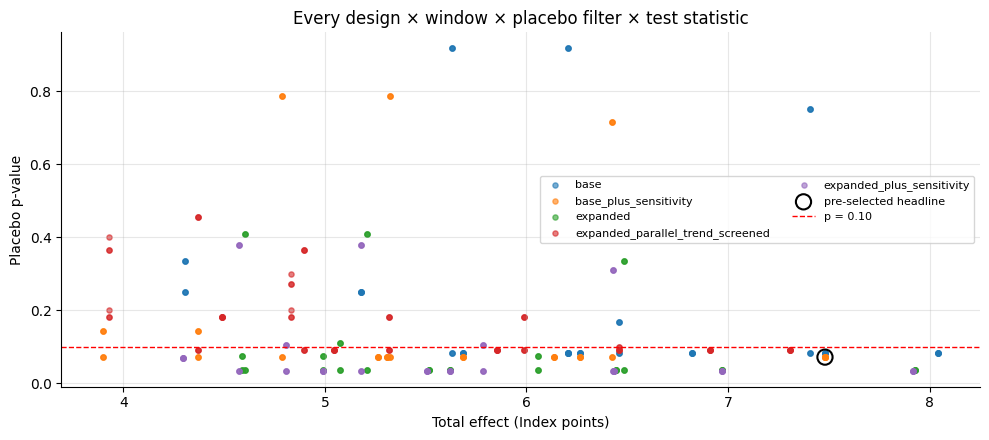

**Figure 3.** 360 specifications. The effect is positive in 100% of them (range +3.90 to +8.04), and 73.3% reach p ≤ 0.10. The direction is robust; most specifications also separate it from rival-brand drift.

In [8]:
curve = pd.read_parquet(T + "specification_curve.parquet")
fig, ax = plt.subplots(figsize=(10, 4.5))
for pool_name, group in curve.groupby("donor_pool"):
    ax.scatter(group["lift_index_points"], group["p_value"], s=14, alpha=0.6, label=pool_name)
prim = curve[curve["is_primary"]]
ax.scatter(prim["lift_index_points"], prim["p_value"], s=120, facecolors="none", edgecolors="black", lw=1.5, label="pre-selected headline")
ax.axhline(0.10, color="red", ls="--", lw=1, label="p = 0.10")
ax.set_xlabel("Total effect (Index points)"); ax.set_ylabel("Placebo p-value")
ax.set_title("Every design × window × placebo filter × test statistic"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
s = est["specification_curve_summary"]
md(f"**Figure 3.** {s['specifications']} specifications. The effect is positive in {100*s['share_lift_positive']:.0f}% of them "
   f"(range {fmt(s['lift_range_index_points'][0], signed=True)} to {fmt(s['lift_range_index_points'][1], signed=True)}), "
   f"and {100*s['share_p_at_or_below_alpha']:.1f}% reach p ≤ 0.10. The direction is robust; "
   f"{'most specifications also separate it from rival-brand drift' if s['share_p_at_or_below_alpha'] > 0.5 else 'separation from rival-brand drift holds in a minority of specifications'}.")

In [9]:
windows = curve[curve["selected_design"] & curve["placebo_filter"].eq("none")].pivot_table(
    index="window", columns="statistic", values=["lift_index_points", "p_value"])
windows.columns = [f"{a} ({b})" for a, b in windows.columns]
display(windows.style.format(precision=3))
md("**Table 3.** Headline design by window and test statistic. 'mean_gap_over_pre_rmspe' is a secondary statistic targeting a sustained "
   "one-directional shift; only the ratio statistic on the full window is the pre-registered headline test.")

,lift_index_points (mean_gap_over_pre_rmspe),lift_index_points (rmspe_ratio),p_value (mean_gap_over_pre_rmspe),p_value (rmspe_ratio)
window,,,,
all_post,7.481,7.481,0.071,0.071
before_spring_2026_surge,5.264,5.264,0.071,0.071
excluding_spring_2026_surge,6.138,6.138,0.071,0.071


**Table 3.** Headline design by window and test statistic. 'mean_gap_over_pre_rmspe' is a secondary statistic targeting a sustained one-directional shift; only the ratio statistic on the full window is the pre-registered headline test.

### 5.4 Media-value weighting (broadcast-inclusive exposure, ADR-0028; original 2024 design on the search-salience index)

In [10]:
mv = json.loads(Path(E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json").read_text())
display(pd.DataFrame([
    {"Weighting (weeks covered by media value)": "Media value (relative intensity, broadcast-inclusive)", "Mean gap (Index points)": mv["media_intensity_weighted_gap_index_points"]},
    {"Weighting (weeks covered by media value)": "Blinkfire FIFA impressions (digital)", "Mean gap (Index points)": mv["blinkfire_weighted_gap_same_window_index_points"]},
    {"Weighting (weeks covered by media value)": "Unweighted", "Mean gap (Index points)": mv["unweighted_mean_gap_same_window_index_points"]},
]).style.format({"Mean gap (Index points)": "{:+.3f}"}).hide(axis="index"))
coef = mv["timing_regression"]["coefficients"]["media_intensity_log_adstock_z"]
md(f"**Table 4.** {mv['window_start']} to {mv['window_end']}, original 11-donor design, in search-salience index points (not Brand Index points). Weeks with more broadcast-inclusive exposure do not show a larger gap "
   f"(timing coefficient {fmt(coef['estimate_index_points'], 3, True)} points per s.d., HAC s.e. {fmt(coef['hac_se'], 3)}): the effect looks cumulative "
   "rather than exposure-driven. Media-value dollar amounts are never used (P1).")

Weighting (weeks covered by media value),Mean gap (Index points)
"Media value (relative intensity, broadcast-inclusive)",+0.863
Blinkfire FIFA impressions (digital),+0.938
Unweighted,+0.806


**Table 4.** 2025-04-28 to 2026-03-30, original 11-donor design, in search-salience index points (not Brand Index points). Weeks with more broadcast-inclusive exposure do not show a larger gap (timing coefficient +0.018 points per s.d., HAC s.e. 0.104): the effect looks cumulative rather than exposure-driven. Media-value dollar amounts are never used (P1).

### 5.5 The spring 2026 category surge (a confounder)

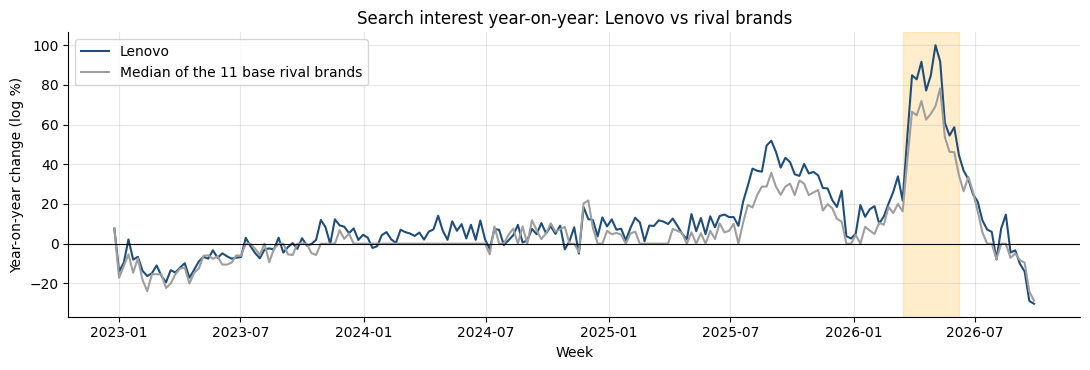

**Figure 4.** Orange band: spring 2026, when searches for every PC brand rose sharply year-on-year (consistent with the memory-shortage price rush). Lenovo reacts more strongly than rivals to such swings, so the gap in that period (+17.33 points over 12 weeks) is partly a category effect. Table 3 shows the effect excluding it.

In [11]:
base = registry.loc[registry["inclusion_policy"].eq("base"), "query_id"].tolist()
dp = donors.copy(); dp["week"] = pd.to_datetime(dp["week"])
pivot = dp[dp["query_id"].isin(base + ["anchor_lenovo"])].groupby(["week", "query_id"])["interest_common_scale"].mean().unstack()
yoy = 100 * np.log(pivot / pivot.shift(52))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(yoy.index, yoy["anchor_lenovo"], label="Lenovo", color="#1f4e79")
ax.plot(yoy.index, yoy[base].median(axis=1), label="Median of the 11 base rival brands", color="#9e9e9e")
ax.axhline(0, color="black", lw=0.8); ax.axvspan(pd.Timestamp("2026-03-15"), pd.Timestamp("2026-06-07"), color="orange", alpha=0.2)
ax.set_ylabel("Year-on-year change (log %)"); ax.set_xlabel("Week"); ax.set_title("Search interest year-on-year: Lenovo vs rival brands")
ax.legend(); plt.tight_layout(); plt.show()
surge = table.set_index("Period").loc["Spring 2026 PC-price surge (confounded)"]
md(f"**Figure 4.** Orange band: spring 2026, when searches for every PC brand rose sharply year-on-year (consistent with the memory-shortage price rush). "
   f"Lenovo reacts more strongly than rivals to such swings, so the gap in that period ({fmt(surge['Mean gap (Index points)'], signed=True)} points over "
   f"{surge['Weeks']} weeks) is partly a category effect. Table 3 shows the effect excluding it.")

### 5.6 Cross-checks: share of search alone, and the former headline

The same engine is run (i) with Lenovo's Google share of search alone as the outcome, the component the rivals can actually reproduce, and (ii) as the former headline (ADR-0038): the superseded search-salience index against rivals' raw search interest. The former headline is in its own units (100/15 scale, about 10% of search interest per point), so compare direction and significance, not size.

In [12]:
rows = []
for label, d in [("Brand Index (headline)", T), ("Google share of search only", SS), ("Search-salience index (former headline)", SAL)]:
    m = json.loads(Path(d + "estimate_manifest.json").read_text())
    c = pd.read_parquet(d + "specification_curve.parquet")
    sel_rows = c[c["selected_design"] & c["placebo_filter"].eq("none") & c["statistic"].eq("rmspe_ratio")].set_index("window")
    rows.append({"Outcome": label, "Design": f"{m['selection']['selected_method']} / {m['selection']['selected_pool']} ({len(m['selection']['selected_donors'])})",
                 "Total effect": m["total_effect"]["lift_index_points"],
                 "Leave-one-out range": f"{m['total_effect']['leave_one_donor_out_range'][0]:+.2f} to {m['total_effect']['leave_one_donor_out_range'][1]:+.2f}",
                 "Placebo p": m["primary"]["p_value"], "Smallest attainable p": 1 / (1 + m["primary"]["placebos_kept"]),
                 "p excl. spring 2026 surge": sel_rows.loc["excluding_spring_2026_surge", "p_value"],
                 "p before the surge": sel_rows.loc["before_spring_2026_surge", "p_value"],
                 "Effect excl. surge": sel_rows.loc["excluding_spring_2026_surge", "lift_index_points"]})
cross = pd.DataFrame(rows).set_index("Outcome")
display(cross.style.format({"Total effect": "{:+.2f}", "Placebo p": "{:.3f}", "Smallest attainable p": "{:.3f}",
                            "p excl. spring 2026 surge": "{:.3f}", "p before the surge": "{:.3f}", "Effect excl. surge": "{:+.2f}"}))
md("**Table 5.** All three agree in direction. Significance is clearest on the headline design; on share of search alone it weakens "
   "once the spring 2026 surge weeks are removed. Each row's design was selected on its own pre-period evidence.")

,Design,Total effect,Leave-one-out range,Placebo p,Smallest attainable p,p excl. spring 2026 surge,p before the surge,Effect excl. surge
Outcome,,,,,,,,
Brand Index (headline),synthetic_did / base_plus_sensitivity (13),+7.48,+6.99 to +9.87,0.071,0.071,0.071,0.071,+6.14
Google share of search only,simplex_scm / expanded (26),+7.20,+6.79 to +8.04,0.074,0.037,0.111,0.222,+5.69
Search-salience index (former headline),simplex_scm / expanded (26),+0.91,+0.88 to +1.19,0.111,0.037,0.222,0.222,+0.63


**Table 5.** All three agree in direction. Significance is clearest on the headline design; on share of search alone it weakens once the spring 2026 surge weeks are removed. Each row's design was selected on its own pre-period evidence.

### 5.7 FIFA or Lenovo's other sponsorships? (exposure timing, ADR-0042)

Lenovo also sponsors Ducati (since 2018), MotoGP (since 2019) and F1 (Official Partner since 2022, **Global Partner from 2025**), and named the Carolina Hurricanes' arena in September 2024. Their digital exposure exceeded FIFA's in most quarters before the World Cup, so the gap could reflect them rather than FIFA.

**Hypothesis (owner).** Sponsorships running before the sample started are part of what the synthetic control was fitted on, so only exposure *above* their pre-FIFA level, plus all FIFA exposure, is incremental.

**Method.** Blinkfire starts in late September 2024, so non-FIFA exposure before then is **back-cast**: each property's observed weekly profile in its first observed year, scaled year by year by its own co-brand Google search level ("Lenovo F1" etc., observed since 2022; not used after June 2025 because of the 2025Q3 Google data change). The pre-FIFA baseline is that profile at the 2022–2024 mean intensity. Then the weekly gap is regressed on standardised log adstock ($\delta = 0.8$) with event controls and Newey–West errors:

$$\text{gap}_t = a + b_F\, z(\log A^{FIFA}_t) + b_N\, z(\log A^{other}_t) + [\text{trend}] + [\text{post step}] + \text{events}_t + e_t .$$

*In words:* does the gap rise in the weeks when exposure is higher, for FIFA and for the other sponsorships separately? Three tests: before FIFA (does motorsport timing move the gap?), after the announcement (FIFA vs exposure *above* the non-FIFA baseline), and the full sample. Each in levels without and with a trend, and in weekly changes. Diagnostic only: the headline is unchanged.

In [13]:
TM = json.loads(Path(E + "sponsorship_exposure_timing_v1/exposure_timing_manifest.json").read_text())
sc = pd.read_parquet(E + "sponsorship_exposure_timing_v1/nonfifa_backcast_scales.parquet")
display(sc[["property_id", "active_from", "upgraded_from", "scale_2022", "scale_2023", "scale_2024", "observed_over_baseline"]].rename(columns={
    "property_id": "Property", "active_from": "Active from", "upgraded_from": "Upgraded from", "scale_2022": "2022 intensity",
    "scale_2023": "2023 intensity", "scale_2024": "2024 intensity", "observed_over_baseline": "Post-announcement exposure ÷ pre-FIFA baseline"})
    .style.format({c: "{:.2f}" for c in ["2022 intensity", "2023 intensity", "2024 intensity", "Post-announcement exposure ÷ pre-FIFA baseline"]}, na_rep="—").hide(axis="index"))
md("**Table 6.** Intensity = the year's co-brand search level relative to the first Blinkfire year (Oct 2024–Jun 2025). "
   "A ratio near 1 in the last column means the sponsorship ran at its usual, pre-FIFA level after the announcement.")

Property,Active from,Upgraded from,2022 intensity,2023 intensity,2024 intensity,Post-announcement exposure ÷ pre-FIFA baseline
ducati,2018-01-01,None,0.43,0.53,0.81,1.99
motogp,2019-05-30,None,0.81,0.87,1.02,1.11
f1,2022-03-10,2025-01-01,0.90,0.95,0.89,1.41


**Table 6.** Intensity = the year's co-brand search level relative to the first Blinkfire year (Oct 2024–Jun 2025). A ratio near 1 in the last column means the sponsorship ran at its usual, pre-FIFA level after the announcement.

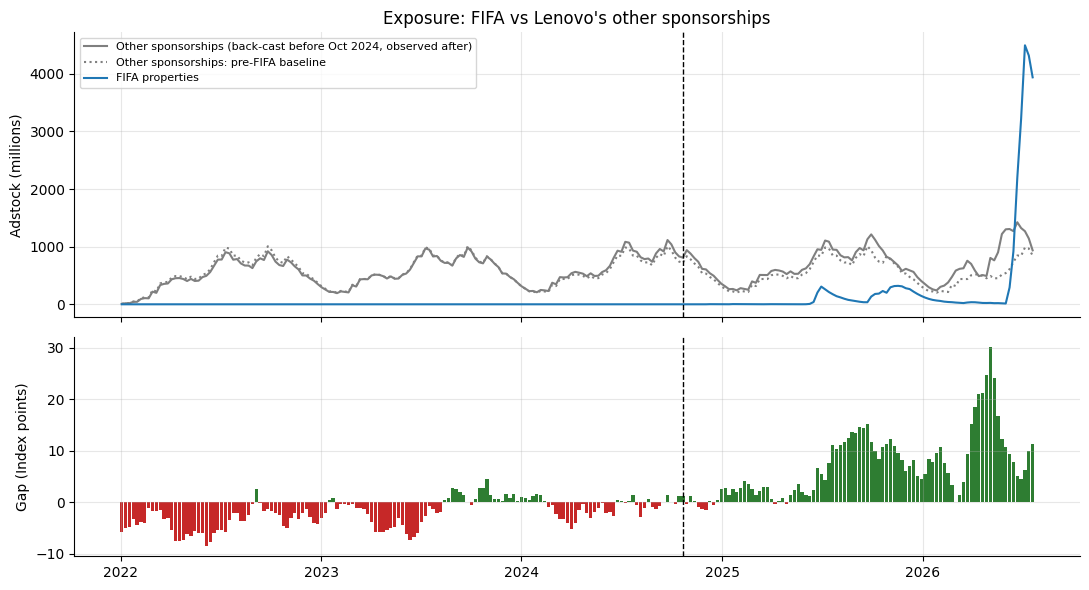

**Figure 5.** Back-cast weeks before late September 2024 are constructed, not observed; exposure after 2026-07-20 is not yet supplied and those weeks are excluded.

In [14]:
tw_ = pd.read_parquet(E + "sponsorship_exposure_timing_v1/exposure_timing_weekly.parquet"); tw_["week"] = pd.to_datetime(tw_["week"])
tw_ = tw_[tw_["exposure_observed"]]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
a1.plot(tw_["week"], tw_["nonfifa_adstock"] / 1e6, color="tab:gray", label="Other sponsorships (back-cast before Oct 2024, observed after)")
a1.plot(tw_["week"], tw_["nonfifa_baseline_adstock"] / 1e6, color="tab:gray", ls=":", label="Other sponsorships: pre-FIFA baseline")
a1.plot(tw_["week"], tw_["fifa_adstock"] / 1e6, color="tab:blue", label="FIFA properties")
a1.axvline(pd.Timestamp(effect["first_post_week"]), color="k", ls="--", lw=1)
a1.set_ylabel("Adstock (millions)"); a1.legend(fontsize=8, loc="upper left"); a1.set_title("Exposure: FIFA vs Lenovo's other sponsorships")
a2.bar(tw_["week"], tw_["index_gap"], width=6, color=np.where(tw_["index_gap"] >= 0, "#2e7d32", "#c62828"))
a2.set_ylabel("Gap (Index points)"); a2.axvline(pd.Timestamp(effect["first_post_week"]), color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()
md(f"**Figure 5.** Back-cast weeks before late September 2024 are constructed, not observed; exposure after "
   f"{TM['samples']['exposure_coverage_end']} is not yet supplied and those weeks are excluded.")

In [15]:
labels = {"pre_period_nonfifa": "Before FIFA: other sponsorships", "post_period_incremental": "After the announcement",
          "full_sample": "Full sample"}
specs = {"levels_without_trend": "levels", "levels_with_trend": "levels + trend",
         "levels_with_trend_and_post_step": "levels + trend + post step", "first_differences": "weekly changes"}
terms = {"fifa_log_adstock": "FIFA exposure", "nonfifa_log_adstock": "Other sponsorships (total)",
         "nonfifa_incremental_log_adstock": "Other sponsorships (above baseline)"}
rows = []
for key, vals in TM["summary"].items():
    test, spec_name = key.split(":")
    for term, v in vals.items():
        if term in terms:
            rows.append({"Test": labels[test], "Specification": specs[spec_name], "Exposure": terms[term],
                         "Points per s.d.": v["points_per_sd"], "HAC s.e.": v["hac_se"], "p": v["p"]})
tt = pd.DataFrame(rows).pivot_table(index=["Test", "Specification"], columns="Exposure", values=["Points per s.d.", "p"], sort=False)
display(tt.style.format("{:+.2f}", subset=[c for c in tt.columns if c[0] == "Points per s.d."]).format("{:.3f}", subset=[c for c in tt.columns if c[0] == "p"], na_rep="—"))
pre_t = TM["summary"]["pre_period_nonfifa:levels_with_trend"]["nonfifa_log_adstock"]
pre_d = TM["summary"]["pre_period_nonfifa:first_differences"]["nonfifa_log_adstock"]
step = TM["summary"]["full_sample:levels_with_trend_and_post_step"]
post_t = TM["summary"]["post_period_incremental:levels_with_trend"]
fd = TM["summary"]["full_sample:first_differences"]
absorbed = pre_t["p"] > 0.10 and pre_d["p"] > 0.10
other_positive = [k for k, v in TM["summary"].items() if "without_trend" not in k for term, x in v.items()
                  if term.startswith("nonfifa") and x["points_per_sd"] > 0 and x["p"] <= 0.10]
fifa_supported = step["fifa_log_adstock"]["points_per_sd"] > 0 and step["fifa_log_adstock"]["p"] <= 0.10
md(f"""**Table 7.** Points of gap per standard deviation of log adstock.
- **Before FIFA**, motorsport exposure {'does not' if absorbed else 'does'} move the gap once a trend is allowed ({pre_t['points_per_sd']:+.2f}, p = {pre_t['p']:.2f}) or week to week ({pre_d['points_per_sd']:+.2f}, p = {pre_d['p']:.2f}): {'its usual exposure is absorbed in the pre-period fit, as hypothesised' if absorbed else 'the hypothesis is not supported'}.
- **Other sponsorships' exposure** {'is not positively associated with the gap in any specification that controls for a trend' if not other_positive else 'is positively associated with the gap in: ' + ', '.join(other_positive)}.
- **FIFA exposure**, with the pre-period trend and an after-announcement step, adds {step['fifa_log_adstock']['points_per_sd']:+.2f} points per s.d. (p = {step['fifa_log_adstock']['p']:.3f}): within the sponsorship period, weeks with more accumulated FIFA exposure have a larger gap.
- **But** it does not respond week to week ({fd['fifa_log_adstock']['points_per_sd']:+.2f}, p = {fd['fifa_log_adstock']['p']:.2f}), and a trend fitted on the post-period alone absorbs it ({post_t['fifa_log_adstock']['points_per_sd']:+.2f}, p = {post_t['fifa_log_adstock']['p']:.2f}); FIFA exposure correlates {TM['post_collinearity']['fifa_log_adstock_vs_time']:.2f} with time after the announcement.""")

**Table 7.** Points of gap per standard deviation of log adstock.
- **Before FIFA**, motorsport exposure does not move the gap once a trend is allowed (-0.01, p = 0.97) or week to week (+0.04, p = 0.62): its usual exposure is absorbed in the pre-period fit, as hypothesised.
- **Other sponsorships' exposure** is not positively associated with the gap in any specification that controls for a trend.
- **FIFA exposure**, with the pre-period trend and an after-announcement step, adds +6.29 points per s.d. (p = 0.001): within the sponsorship period, weeks with more accumulated FIFA exposure have a larger gap.
- **But** it does not respond week to week (+0.12, p = 0.20), and a trend fitted on the post-period alone absorbs it (-1.27, p = 0.45); FIFA exposure correlates 0.78 with time after the announcement.

### 5.8 The FIFA-specific effect (primary estimate, ADR-0043)

The weekly gap is split into the parts explained by each driver in the full-sample regression with a trend (section 5.7):

$$\overline{\text{gap}}_{post} = \underbrace{\hat b_F\, \overline{z(\log A^{FIFA})}_{post}}_{\text{FIFA-specific}} + \underbrace{\hat b_N\, \overline{\Delta z(\log A^{other})}_{post}}_{\text{other sponsorships}} + \underbrace{\textstyle\sum_e \hat c_e\, \bar e_{post}}_{\text{events}} + \text{residual},$$

where the FIFA term is measured from zero FIFA exposure and the other-sponsorship term from its pre-FIFA baseline. *In words:* how much of the post-announcement gap the accumulated FIFA exposure accounts for, beyond the pre-period trend; what is left unexplained (a slow Lenovo-specific drift, or FIFA effects the exposure measure misses) is the residual.

**Bands.** (i) Statistical: the FIFA part ± 1.96 × its Newey–West standard error. (ii) Attribution: the whole gap over the same weeks, i.e. the residual also credited to FIFA. Uplifts in % divide by the twin's mean level over the same weeks (the index is proportional to brand share).

In [16]:
FS = TM["fifa_specific_effect"]
d = FS["decomposition_index_points"]
display(pd.DataFrame([
    ("FIFA-specific effect (primary)", d["fifa"], FS["primary_uplift_pct"]),
    ("Other sponsorships (above pre-FIFA baseline)", d["other_sponsorships"], None),
    ("Lenovo events", d["events"], None),
    ("Residual (trend, unexplained)", d["residual"], None),
    ("Total gap, same weeks (attribution upper band)", d["total_gap"], FS["attribution_band_upper_uplift_pct"]),
], columns=["Component", "Index points", "% brand share"]).style.format({"Index points": "{:+.2f}", "% brand share": "{:+.1f}%"}, na_rep="—").hide(axis="index"))
dec = pd.read_parquet(E + "sponsorship_exposure_timing_v1/fifa_specific_decomposition.parquet")
display(dec.assign(specification=dec["test"] + " / " + dec["specification"])[["specification", "fifa", "other_sponsorships", "events", "residual"]]
        .rename(columns={"specification": "Specification", "fifa": "FIFA", "other_sponsorships": "Other sponsorships", "events": "Events", "residual": "Residual"})
        .style.format({c: "{:+.2f}" for c in ["FIFA", "Other sponsorships", "Events", "Residual"]}).hide(axis="index"))
md(f"""**Tables 8–9.** {FS['weeks']} weeks with Blinkfire coverage ({FS['period'][0]} to {FS['period'][1]}); twin level {FS['counterfactual_index_level']:.1f}.
**Primary: {FS['primary_index_points']:+.2f} points ≈ {FS['primary_uplift_pct']:+.1f}% brand share**; 95% band {FS['statistical_band_95_index_points'][0]:+.2f} to {FS['statistical_band_95_index_points'][1]:+.2f}
({FS['statistical_band_95_uplift_pct'][0]:+.1f}% to {FS['statistical_band_95_uplift_pct'][1]:+.1f}%); attribution upper band {FS['attribution_band_upper_index_points']:+.2f} ({FS['attribution_band_upper_uplift_pct']:+.1f}%).
Table 9 shows why one specification is fixed as primary: the other levels specifications give FIFA between {FS['specification_range_fifa_index_points'][0]:+.1f} and {FS['specification_range_fifa_index_points'][1]:+.1f} points, either over-attributing (negative residual, extrapolating from zero FIFA exposure)
or letting a trend fitted on the post-period alone absorb FIFA's cumulative build-up.""")

Component,Index points,% brand share
FIFA-specific effect (primary),+4.42,+4.3%
Other sponsorships (above pre-FIFA baseline),+0.02,—
Lenovo events,-0.19,—
"Residual (trend, unexplained)",+2.78,—
"Total gap, same weeks (attribution upper band)",+7.03,+6.9%


Specification,FIFA,Other sponsorships,Events,Residual
post_period_incremental / levels_without_trend,+18.81,+0.47,-0.28,-11.97
post_period_incremental / levels_with_trend,-7.69,-2.47,-0.23,+17.42
full_sample / levels_without_trend,+9.56,+0.22,-0.16,-2.60
full_sample / levels_with_trend,+4.42,+0.02,-0.19,+2.78
full_sample / levels_with_trend_and_post_step,+12.64,-0.03,-0.22,-5.36


**Tables 8–9.** 92 weeks with Blinkfire coverage (2024-10-21 to 2026-07-20); twin level 102.0.
**Primary: +4.42 points ≈ +4.3% brand share**; 95% band +1.70 to +7.13
(+1.7% to +7.0%); attribution upper band +7.03 (+6.9%).
Table 9 shows why one specification is fixed as primary: the other levels specifications give FIFA between -7.7 and +18.8 points, either over-attributing (negative residual, extrapolating from zero FIFA exposure)
or letting a trend fitted on the post-period alone absorb FIFA's cumulative build-up.

### 5.9 Does leaving television out matter? (ADR-0046)

The FIFA exposure measure counts **social media impressions only** (Blinkfire). The only measure that includes **television** is the client's media-value export, which covers May 2025 to March 2026: it misses the announcement months and the 2026 World Cup. Media value is used here only as a **unitless weekly intensity**, never as money (P1, ADR-0028).

**Television intensity.** With $V_t$ the weekly quality-adjusted media value,

$$\text{TV}_t = \log\!\Big(1 + \frac{A^V_t}{\overline{A^V}_{obs}}\Big), \qquad A^V_t = V_t + 0.80\, A^V_{t-1},$$

i.e. the same 80% weekly carryover as social media, scaled by its own mean over the observed weeks so that no amount survives. It is zero before May 2025: certain before the deal, assumed for October 2024 to April 2025.

**Simulating the World Cup.** Media value is almost entirely match-driven. A value per match by stage $s$ (group, knockout, semi-final/final) is fitted on the 2025 Club World Cup:

$$V_w \approx \textstyle\sum_s m_{s,w}\, v_s,$$

where $m_{s,w}$ is the number of stage-$s$ matches in week $w$ (official schedules). The fitted $v_s$ are applied to the 104 World Cup matches and multiplied by a tournament scale $k$ (four scenarios). The production regression of section 5.8 is then re-run with $\text{TV}_t$ as a second FIFA exposure channel; its contribution counts as FIFA.

In [17]:
TV = json.loads(Path(E + "tv_exposure_check_v1/tv_exposure_check_manifest.json").read_text())
cal_ = pd.DataFrame(TV["calibration"]["weekly"])
display(cal_.rename(columns={"week": "Week", "group": "Group matches", "knockout": "Knockout", "late": "Semi-final / final",
                             "observed_share": "Observed media value (share)", "fitted_share": "Fitted (share)"})
        .style.format({"Observed media value (share)": "{:.3f}", "Fitted (share)": "{:.3f}"}).hide(axis="index"))
v = TV["calibration"]["value_per_match_relative_to_group"]
md(f"**Table 10.** Calibration on the {TV['calibration']['competition']} ({TV['calibration']['matches']} matches); shares of its total media value. "
   f"Value per match relative to a group match: knockout {v['knockout']:.2f}×, semi-final/final {v['late']:.2f}×; weekly fit correlation {TV['calibration']['fit_weekly_correlation']:.2f}; "
   f"{TV['calibration']['tail_share_week_after_final']:.0%} of the final week carries into the week after. Source: {TV['calibration']['source']}.")
ow = TV["observed_window"]
ov = TV["overlap"]
display(pd.DataFrame([
    ("Social media only (production measure)", ow["social_only"]["fifa_total"], ow["social_only"]["social_part"], None, None, ow["social_only"]["not_attributed"]),
    ("Social media + television", ow["social_and_tv"]["fifa_total"], ow["social_and_tv"]["social_part"], ow["social_and_tv"]["tv_part"], ow["social_and_tv"]["p_tv"], ow["social_and_tv"]["not_attributed"]),
    ("Television only", ow["tv_only"]["fifa_total"], None, ow["tv_only"]["tv_part"], ow["tv_only"]["p_tv"], ow["tv_only"]["not_attributed"]),
], columns=["Exposure measure", "FIFA total", "Social media part", "Television part", "p (television)", "Not attributed"])
  .style.format({c: "{:+.2f}" for c in ["FIFA total", "Social media part", "Television part", "Not attributed"]} | {"p (television)": "{:.3f}"}, na_rep="—").hide(axis="index"))
md(f"**Table 11.** Observed window: weeks to {ow['to']} ({ow['social_only']['post_weeks']} post-announcement weeks), Brand Index points. On the {ov['weeks']} weeks both series cover, "
   f"television and social media correlate at {ov['corr_tv_vs_social_weekly']:.2f} week by week; television correlates with the gap at {ov['corr_tv_vs_gap']:.2f}, social media at {ov['corr_social_vs_gap']:.2f}.")

Week,Group matches,Knockout,Semi-final / final,Observed media value (share),Fitted (share)
2025-06-09,5,0,0,0.066,0.065
2025-06-16,27,0,0,0.349,0.353
2025-06-23,16,4,0,0.306,0.300
2025-06-30,0,8,0,0.179,0.182
2025-07-07,0,0,3,0.100,0.100


**Table 10.** Calibration on the FIFA Club World Cup (63 matches); shares of its total media value. Value per match relative to a group match: knockout 1.74×, semi-final/final 2.54×; weekly fit correlation 1.00; 5% of the final week carries into the week after. Source: FIFA, Club World Cup 2025 match schedule (fifa.com).

Exposure measure,FIFA total,Social media part,Television part,p (television),Not attributed
Social media only (production measure),+4.96,+4.96,—,—,+0.47
Social media + television,+4.23,+3.09,+1.14,0.094,+1.20
Television only,+1.65,—,+1.65,0.014,+3.78


**Table 11.** Observed window: weeks to 2026-03-30 (76 post-announcement weeks), Brand Index points. On the 49 weeks both series cover, television and social media correlate at 0.61 week by week; television correlates with the gap at 0.21, social media at 0.52.

World Cup television scenario,World Cup / Club World Cup,FIFA total,Social media part,Television part,p (television),Television only,Change vs primary
Same value per match as the Club World Cup,1.7×,+4.69,+5.06,-0.37,0.61,+0.33,+0.27
Three times the Club World Cup audience (assumed),5.2×,+4.74,+5.21,-0.47,0.41,+0.09,+0.32
Scaled by Blinkfire impressions per match,18.4×,+4.72,+5.19,-0.47,0.27,-0.05,+0.30
Proportional to weekly Blinkfire FIFA impressions,19.0×,+4.71,+5.16,-0.45,0.31,-0.02,+0.30


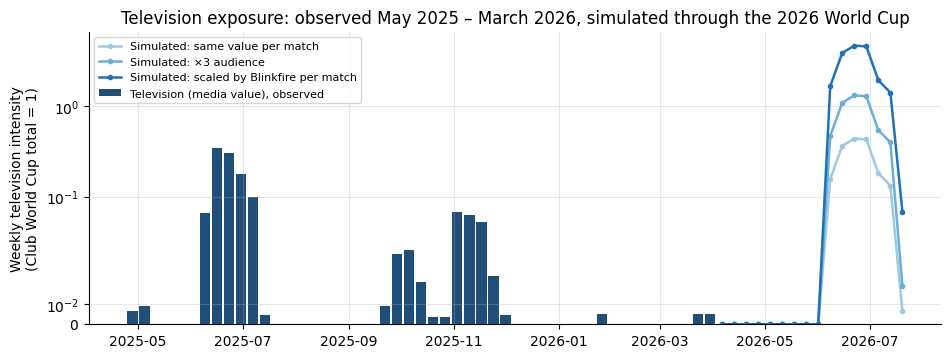

**Table 12 and figure.** Full production sample, Brand Index points; primary FIFA-specific effect +4.42
(95% band +1.70 to +7.13). With simulated World Cup television, the FIFA total is
+4.69 to +4.74 under every scale (at most 0.32 points from the primary;
within its band). The television term is -0.47 to -0.37, not significant
(p 0.27–0.61): the small rise comes from the overlap with social media, not from a television effect.
Holding the production model fixed, its weekly error does not rise with television exposure (slope -1.08 points per s.d.; World Cup weeks fall below the model,
as the spring 2026 category surge unwinds, section 5.5).

In [18]:
sc = pd.DataFrame(TV["scenarios"])
display(sc[["label", "world_cup_vs_club_world_cup", "fifa_total_with_tv", "social_part", "tv_part", "p_tv", "fifa_total_tv_only", "change_vs_primary"]]
        .rename(columns={"label": "World Cup television scenario", "world_cup_vs_club_world_cup": "World Cup / Club World Cup",
                         "fifa_total_with_tv": "FIFA total", "social_part": "Social media part", "tv_part": "Television part",
                         "p_tv": "p (television)", "fifa_total_tv_only": "Television only", "change_vs_primary": "Change vs primary"})
        .style.format({"World Cup / Club World Cup": "{:.1f}×", "FIFA total": "{:+.2f}", "Social media part": "{:+.2f}", "Television part": "{:+.2f}",
                       "p (television)": "{:.2f}", "Television only": "{:+.2f}", "Change vs primary": "{:+.2f}"}).hide(axis="index"))
tw = pd.read_parquet(E + "tv_exposure_check_v1/tv_exposure_weekly_relative.parquet"); tw["week"] = pd.to_datetime(tw["week"])
fig, ax = plt.subplots(figsize=(11, 3.8))
obs = tw[tw["tv_source"].eq("observed")]
ax.bar(obs["week"], obs["same_per_match"], width=6, color="#1f4e79", label="Television (media value), observed")
sim = tw[tw["tv_source"].eq("simulated")]
for col_, c_, lab in [("same_per_match", "#9ecae1", "Simulated: same value per match"), ("audience_x3", "#6baed6", "Simulated: ×3 audience"),
                      ("blinkfire_per_match", "#2171b5", "Simulated: scaled by Blinkfire per match")]:
    ax.plot(sim["week"], sim[col_], color=c_, lw=1.8, marker="o", ms=3, label=lab)
ax.set_yscale("symlog", linthresh=0.05)
ax.set_ylabel("Weekly television intensity\n(Club World Cup total = 1)")
ax.set_title("Television exposure: observed May 2025 – March 2026, simulated through the 2026 World Cup")
ax.legend(fontsize=8, loc="upper left"); plt.show()
s_ = TV["summary"]
md(f"""**Table 12 and figure.** Full production sample, Brand Index points; primary FIFA-specific effect {TV['primary_fifa_specific_index_points']:+.2f}
(95% band {TV['primary_band_95_index_points'][0]:+.2f} to {TV['primary_band_95_index_points'][1]:+.2f}). With simulated World Cup television, the FIFA total is
{s_['fifa_total_with_tv_range'][0]:+.2f} to {s_['fifa_total_with_tv_range'][1]:+.2f} under every scale (at most {s_['max_change_vs_primary_index_points']:.2f} points from the primary;
{'within' if s_['within_primary_band'] else 'outside'} its band). The television term is {s_['tv_part_range'][0]:+.2f} to {s_['tv_part_range'][1]:+.2f}, not significant
(p {s_['tv_p_range'][0]:.2f}–{s_['tv_p_range'][1]:.2f}): the small rise comes from the overlap with social media, not from a television effect.
Holding the production model fixed, its weekly error does not rise with television exposure (slope {sc['model_error_slope_per_sd'].mean():+.2f} points per s.d.; World Cup weeks fall below the model,
as the spring 2026 category surge unwinds, section 5.5).""")

## 6. Interpretation

In [19]:
pct = 100 * effect["lift_index_points"] / effect["synthetic_post_mean_index"]
ex = windows.loc["excluding_spring_2026_surge"]
FS = TM["fifa_specific_effect"]
md(f"""- **Primary, FIFA-specific effect:** accumulated FIFA exposure accounts for **{FS['primary_index_points']:+.2f} Brand Index points ≈ {FS['primary_uplift_pct']:+.1f}% brand share of attention**
  ({FS['period'][0]} to {FS['period'][1]}), 95% band {FS['statistical_band_95_uplift_pct'][0]:+.1f}% to {FS['statistical_band_95_uplift_pct'][1]:+.1f}%, attribution upper band {FS['attribution_band_upper_uplift_pct']:+.1f}%
  (section 5.8). Lenovo's other sponsorships account for {FS['decomposition_index_points']['other_sponsorships']:+.2f} points and events for {FS['decomposition_index_points']['events']:+.2f}; {FS['decomposition_index_points']['residual']:+.2f} points remain unexplained.
- **Total effect (upper attribution band):** over the sponsorship so far ({effect['post_weeks']} weeks, {effect['first_post_week']} to {effect['last_week']}), Lenovo's Brand Index is on average
  **{fmt(effect['lift_index_points'], signed=True)} points** above its no-sponsorship twin, about **{fmt(pct, 1, True)}% more brand share of attention**
  (the index is proportional to brand share; twin level ≈ {fmt(effect['synthetic_post_mean_index'], 1)}).
- **Robustness:** positive in every one of {s['specifications']} specifications; {fmt(effect['leave_one_donor_out_range'][0], signed=True)} to
  {fmt(effect['leave_one_donor_out_range'][1], signed=True)} leaving out any one rival; {fmt(ex['lift_index_points (rmspe_ratio)'], signed=True)} excluding the spring 2026 surge.
- **FIFA or other sponsorships:** {'the gap builds with accumulated FIFA exposure' if fifa_supported else 'the gap does not build with FIFA exposure'}
  {'and not with' if not other_positive else 'and also with'} Lenovo's other sponsorships{', whose usual exposure is absorbed in the pre-period' if absorbed else ''} (section 5.7).
  {'It does not respond to week-to-week exposure, so a slow brand-building effect and a slow Lenovo-specific drift remain hard to tell apart.' if fd['fifa_log_adstock']['p'] > 0.10 else 'It also responds week to week.'}
- **Uncertainty:** the pre-registered placebo test gives p = {fmt(p['p_value'], 3)} ({'within' if p['p_value'] <= 0.10 else 'outside'} the 0.10 threshold;
  smallest attainable {fmt(1/(1+p['placebos_kept']), 3)}): {len(above)} of {p['placebos_kept']} rival brands drift as far from their own twins.
  Table 5 shows the significance is not robust on every check (share of search alone, without the spring 2026 surge: p = {fmt(cross.loc['Google share of search only', 'p excl. spring 2026 surge'], 3)}).
- **Television:** leaving television out does not bias the FIFA-specific effect: adding a broadcast-inclusive measure, observed or simulated through the World Cup, moves it by at most {TV['summary']['max_change_vs_primary_index_points']:.1f} points (section 5.9).
- **Decision relevance:** report the FIFA-specific effect, about {FS['primary_uplift_pct']:.0f}% in brand share of attention (band {FS['statistical_band_95_uplift_pct'][0]:.0f}–{FS['attribution_band_upper_uplift_pct']:.0f}%),
  **borderline significant** as a whole; it becomes decision-grade if further post-sponsorship weeks keep it in place across the checks.""")

- **Primary, FIFA-specific effect:** accumulated FIFA exposure accounts for **+4.42 Brand Index points ≈ +4.3% brand share of attention**
  (2024-10-21 to 2026-07-20), 95% band +1.7% to +7.0%, attribution upper band +6.9%
  (section 5.8). Lenovo's other sponsorships account for +0.02 points and events for -0.19; +2.78 points remain unexplained.
- **Total effect (upper attribution band):** over the sponsorship so far (100 weeks, 2024-10-21 to 2026-09-14), Lenovo's Brand Index is on average
  **+7.48 points** above its no-sponsorship twin, about **+7.3% more brand share of attention**
  (the index is proportional to brand share; twin level ≈ 102.0).
- **Robustness:** positive in every one of 360 specifications; +6.99 to
  +9.87 leaving out any one rival; +6.14 excluding the spring 2026 surge.
- **FIFA or other sponsorships:** the gap builds with accumulated FIFA exposure
  and not with Lenovo's other sponsorships, whose usual exposure is absorbed in the pre-period (section 5.7).
  It does not respond to week-to-week exposure, so a slow brand-building effect and a slow Lenovo-specific drift remain hard to tell apart.
- **Uncertainty:** the pre-registered placebo test gives p = 0.071 (within the 0.10 threshold;
  smallest attainable 0.071): 0 of 13 rival brands drift as far from their own twins.
  Table 5 shows the significance is not robust on every check (share of search alone, without the spring 2026 surge: p = 0.111).
- **Television:** leaving television out does not bias the FIFA-specific effect: adding a broadcast-inclusive measure, observed or simulated through the World Cup, moves it by at most 0.3 points (section 5.9).
- **Decision relevance:** report the FIFA-specific effect, about 4% in brand share of attention (band 2–7%),
  **borderline significant** as a whole; it becomes decision-grade if further post-sponsorship weeks keep it in place across the checks.

## 7. Limitations and non-claims

- **Brand share of attention, not full brand equity.** The Brand Index measures Lenovo's position in search against rivals, corroborated by the survey; it does not measure preference or purchase directly. Rivals have no survey series, so the twin reproduces the search component only.
- **Not proven causal.** The design is causal in intent, but the significance is borderline and not robust across every check, so the lift is not yet cleanly distinguishable from relative drift among tech brands.
- **Confounding.** The spring 2026 PC-price surge, Lenovo-specific news (record results, share-price rally), product launches and the 2025 F1 upgrade fall inside the sponsorship period. The headline does not control for them; window exclusions (Table 3) and the exposure-timing diagnostic (section 5.7) test, but do not remove, their influence. The back-cast motorsport exposure is constructed from a repeated profile and co-brand search, not observed.
- **One treated brand, one realisation.** The design was chosen on pre-period fit; the post period cannot be replicated.
- **Donor screening is evidence-bounded.** "No FIFA sponsorship found" is not proof of none.
- **Provisional data.** The last two weeks of each Google Trends pull are excluded and the latest weeks will be revised.
- **Statistical vs unmodelled uncertainty.** The placebo p-value captures rival-brand drift, not Trends sampling error, index-model error or screening mistakes.
- **The FIFA-specific split is a regression decomposition, not an experiment.** It depends on the chosen specification (Table 9), on log adstock as the exposure measure, on back-cast motorsport exposure before September 2024 and on social media exposure only (section 5.9 tests the television omission; its World Cup weeks are simulated and overlap social media by construction); the primary specification was fixed by the owner after the decomposition was seen (ADR-0043).
- **Outcome changed after earlier results were seen.** The Brand Index was redesigned (ADR-0039/0040) for construct validity after the former headline (p = 0.111) was known; its clearer p-value must not be read as stronger evidence on its own. Table 5 keeps the former headline visible.

## Next steps

1. Re-estimate after each data refresh; the next pull after 18 October 2026 adds the full World Cup persistence window.
2. Test the effect on survey-based brand metrics with the GWI Q2/Q3 2026 waves.
3. Request the June–July 2026 media-value rows (World Cup) and re-run `tv_exposure_check_v1` on observed television (ADR-0046).
4. Keep this notebook synchronized: `python -m srmp.review` after every rebuild.